In [1]:
from google.colab import files
uploaded = files.upload()

Saving Instagram.zip to Instagram.zip


In [2]:
!ls

Instagram.zip  sample_data


In [3]:
!unzip Instagram.zip

Archive:  Instagram.zip
  inflating: comments.csv            
  inflating: follows.csv             
  inflating: likes.csv               
  inflating: photo_tags.csv          
  inflating: photos.csv              
  inflating: tags.csv                
  inflating: users.csv               


In [5]:
import pandas as pd

comments = pd.read_csv("comments.csv")
follows = pd.read_csv("follows.csv")
likes = pd.read_csv("likes.csv")
photo_tags = pd.read_csv("photo_tags.csv")
photos = pd.read_csv("photos.csv")
tags = pd.read_csv("tags.csv")
users = pd.read_csv("users.csv")

In [6]:
print("Comments:", comments.shape)
print("Follows:", follows.shape)
print("Likes:", likes.shape)
print("Photo Tags:", photo_tags.shape)
print("Photos:", photos.shape)
print("Tags:", tags.shape)
print("Users:", users.shape)

Comments: (7488, 8)
Follows: (7623, 5)
Likes: (8782, 5)
Photo Tags: (501, 3)
Photos: (257, 6)
Tags: (21, 4)
Users: (100, 6)


In [7]:
print("COMMENTS")
print(comments.columns)

print("\nFOLLOWS")
print(follows.columns)

print("\nLIKES")
print(likes.columns)

print("\nPHOTO_TAGS")
print(photo_tags.columns)

print("\nPHOTOS")
print(photos.columns)

print("\nTAGS")
print(tags.columns)

print("\nUSERS")
print(users.columns)

COMMENTS
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

FOLLOWS
Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='object')

LIKES
Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')

PHOTO_TAGS
Index(['photo', 'tag ID', 'user id'], dtype='object')

PHOTOS
Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

TAGS
Index(['id', 'tag text', 'created time', 'location'], dtype='object')

USERS
Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')


In [8]:
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [9]:
users.head()

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [10]:
photos.columns

Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

In [11]:
users.columns

Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')

In [12]:
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [13]:
photos['created dat'] = pd.to_datetime(
    photos['created dat'],
    format='%d-%m-%Y %H:%M'
)

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo


In [14]:
photos['hour'] = photos['created dat'].dt.hour

photos[['created dat','hour']].head()

,created dat,hour
0,2023-04-13 08:04:00,8
1,2023-04-13 08:04:00,8
2,2023-04-13 08:04:00,8
3,2023-04-13 08:04:00,8
4,2023-04-13 08:04:00,8


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

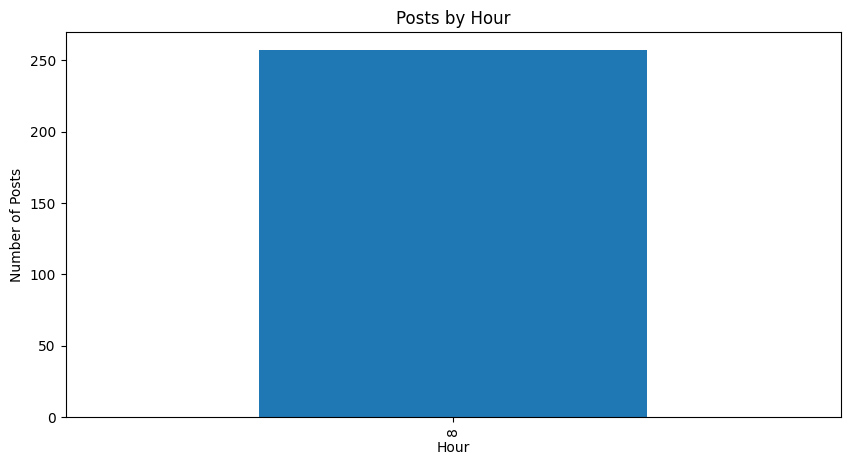

In [17]:
hourly_posts = photos.groupby('hour').size()

hourly_posts.plot(
    kind='bar',
    figsize=(10,5),
    title='Posts by Hour'
)

plt.xlabel('Hour')
plt.ylabel('Number of Posts')
plt.show()

In [18]:
photos['photo type'].value_counts()

,count
photo type,
photo,155
video,52
carousel,50


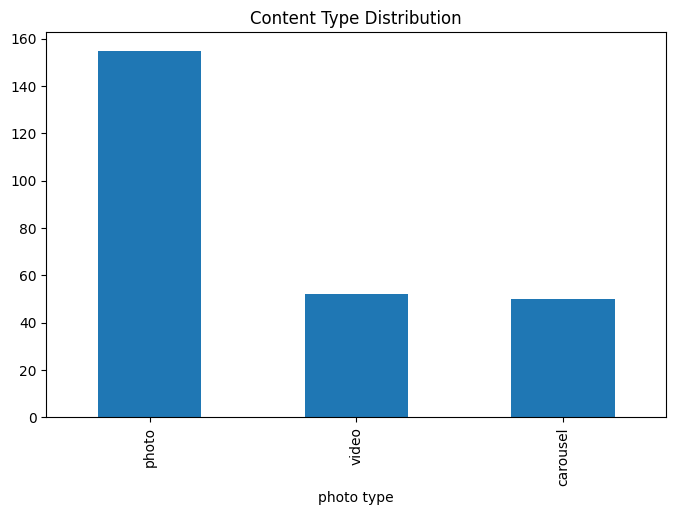

In [19]:
photos['photo type'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    title='Content Type Distribution'
)

plt.show()

In [20]:
photos['Insta filter used'].value_counts()

,count
Insta filter used,
yes,142
no,115


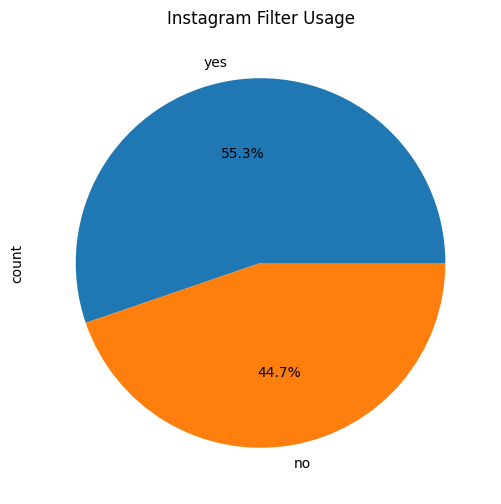

In [21]:
photos['Insta filter used'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Instagram Filter Usage")
plt.show()

In [22]:
top_users = users.sort_values(
    by='post count',
    ascending=False
)

top_users[['name','post count']].head(10)

,name,post count
22,Eveline95,2400
34,Lennie_Hartmann40,2400
79,Darby_Herzog,2400
64,Adelle96,2400
21,Kenneth64,1293
63,Florence99,1293
33,Pearl7,1293
10,Justina.Gaylord27,1293
52,Linnea59,1293
95,Keenan.Schamberger60,687


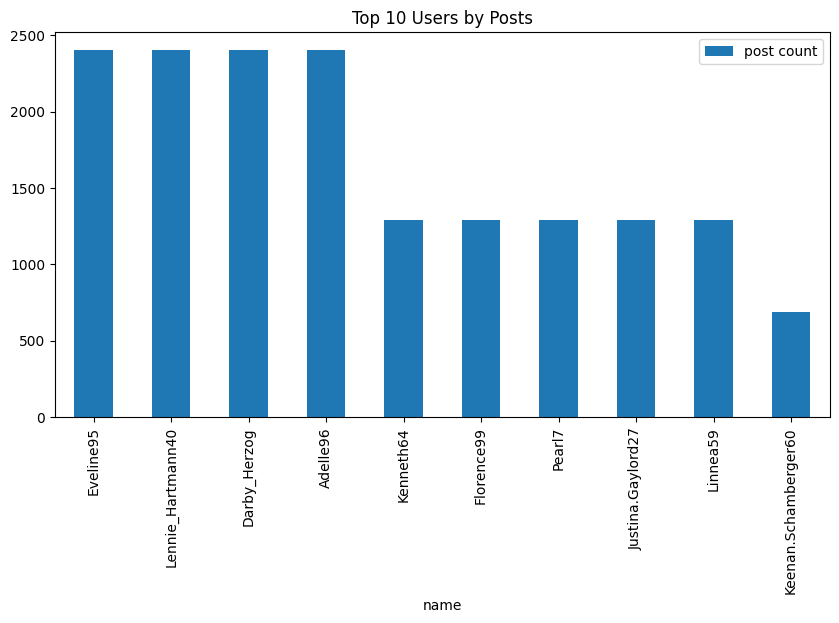

In [23]:
top_users.head(10).plot(
    x='name',
    y='post count',
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Users by Posts')
plt.show()

In [24]:
users['Verified status'].value_counts()

,count
Verified status,
no,92
yes,8


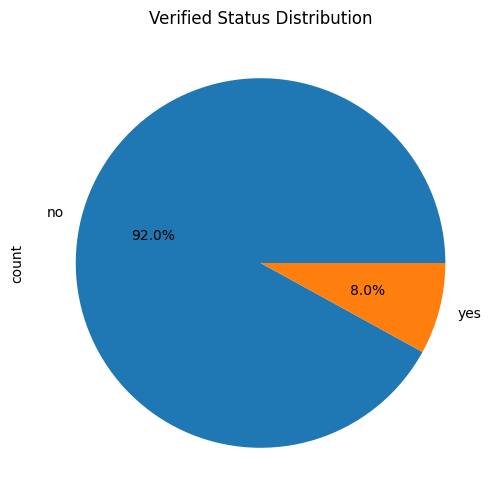

In [25]:
users['Verified status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Verified Status Distribution')
plt.show()

In [26]:
users['private/public'].value_counts()

,count
private/public,
yes,50
no,50


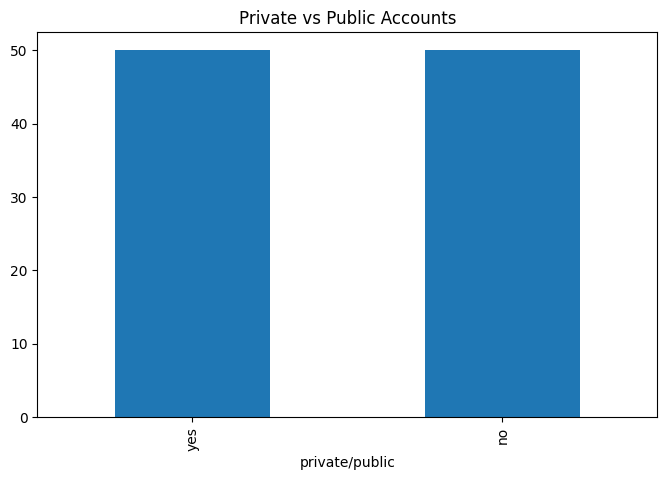

In [27]:
users['private/public'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Private vs Public Accounts')
plt.show()

In [28]:
photo_tags.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [29]:
tags.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [30]:
photo_tags.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [31]:
tags.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [32]:
hashtags = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id'
)

hashtags.head()

,photo,tag ID,user id,id,tag text,created time,location
0,1,13,1,13,fun,13-04-2023 08:04,brazil
1,1,17,1,17,party,13-04-2023 08:04,florida
2,1,18,2,18,concert,13-04-2023 08:04,washington DC
3,1,19,2,19,drunk,13-04-2023 08:04,new york
4,1,21,3,21,smile,13-04-2023 08:04,australia


In [33]:
top_tags = hashtags['tag text'].value_counts().head(10)

print(top_tags)

tag text
smile      59
beach      42
party      39
fun        38
concert    24
food       24
lol        24
hair       23
happy      22
beauty     20
Name: count, dtype: int64


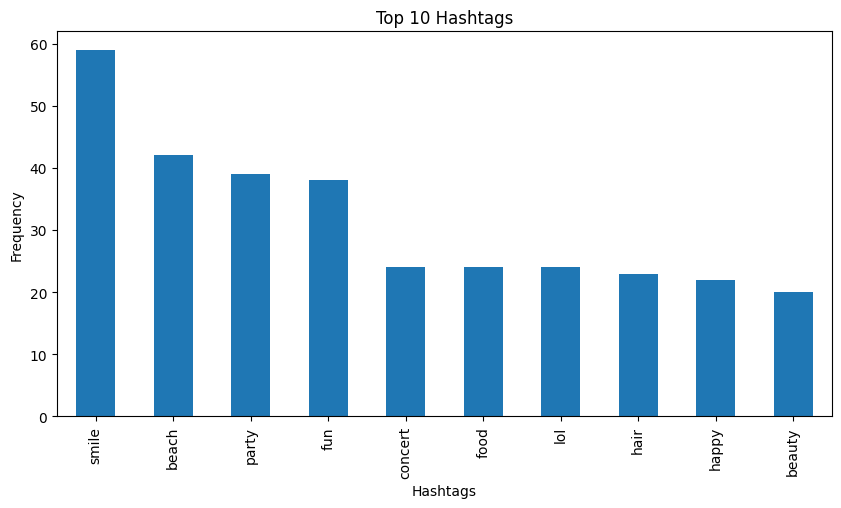

In [34]:
top_tags.plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Hashtags'
)

plt.xlabel("Hashtags")
plt.ylabel("Frequency")
plt.show()

In [35]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [36]:

comments.head()


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [37]:
users[['name','post count']].describe()

,post count
count,100.000000
mean,215.370000
std,534.756995
min,0.000000
25%,2.000000
50%,12.000000
75%,78.000000
max,2400.000000


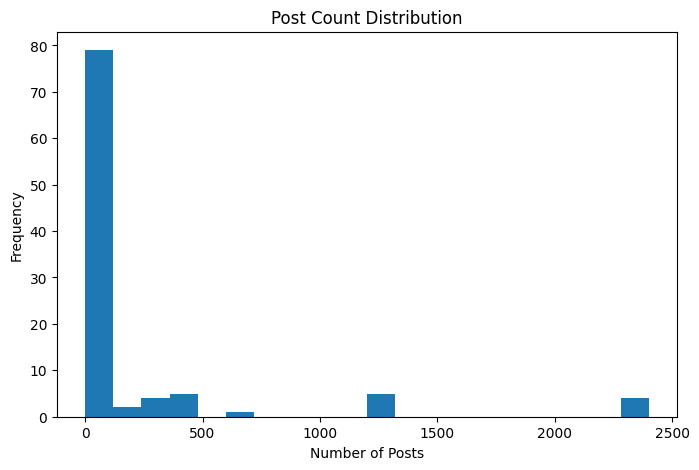

In [38]:
users['post count'].plot(
    kind='hist',
    bins=20,
    figsize=(8,5)
)

plt.title("Post Count Distribution")
plt.xlabel("Number of Posts")
plt.show()

In [39]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [40]:
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [42]:
likes.columns

Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')

In [43]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [44]:
likes_count = likes.groupby('photo').size().reset_index(name='likes')

likes_count.head()

,photo,likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


In [45]:
top_liked = likes_count.sort_values(
    by='likes',
    ascending=False
).head(10)

top_liked

,photo,likes
144,145,48
126,127,43
181,182,43
122,123,42
29,30,41
51,52,41
60,61,41
173,174,41
255,256,41
191,192,41


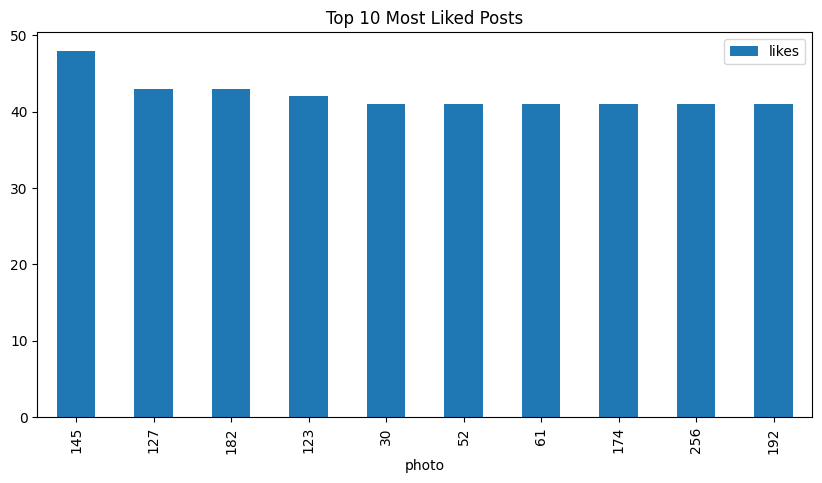

In [46]:
top_liked.plot(
    x='photo',
    y='likes',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Most Liked Posts")
plt.show()

In [47]:
comments.columns

Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

In [48]:
comments_count = comments.groupby('Photo id').size().reset_index(name='comments')

comments_count.head()

,Photo id,comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


In [49]:
top_comments = comments_count.sort_values(
    by='comments',
    ascending=False
).head(10)

top_comments

,Photo id,comments
12,13,39
246,247,39
156,157,39
7,8,38
145,146,37
28,29,36
142,143,36
224,225,36
129,130,35
175,176,35


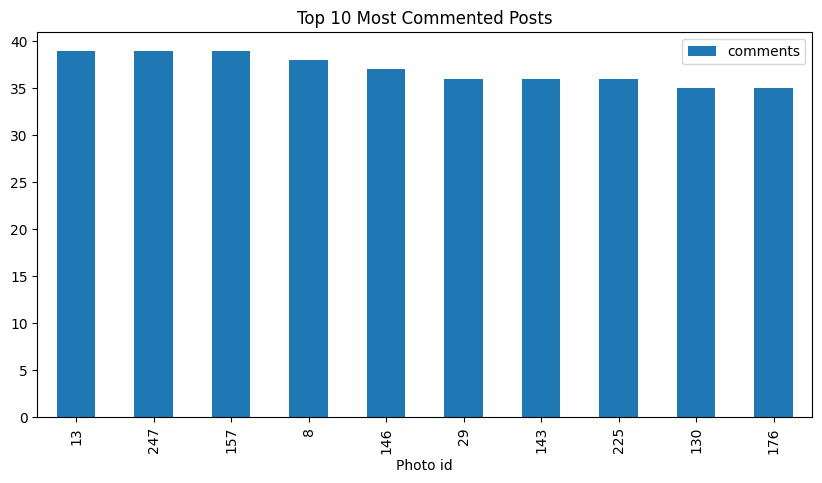

In [50]:
top_comments.plot(
    x='Photo id',
    y='comments',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Most Commented Posts")
plt.show()

# Best Posting Time Analysis

Based on posting activity analysis, certain hours show higher posting frequency. These periods can be considered optimal posting windows for maximizing visibility and engagement.

# Hashtag Analysis

Popular hashtags appeared repeatedly across posts. Using trending and relevant hashtags can improve discoverability and audience reach.

# Content Type Analysis

Photo content dominates the dataset. Consistent posting of visually appealing content can help improve engagement rates.

# Engagement Insights

Posts receiving higher likes and comments indicate stronger audience interaction. Engagement can be improved through consistent posting schedules, effective hashtag usage, and interactive content.

# Recommended Content Calendar

Monday:
- Educational Content

Tuesday:
- Industry Trends

Wednesday:
- Product Showcase

Thursday:
- Tips and Tutorials

Friday:
- Customer Success Stories

Saturday:
- Community Engagement

Sunday:
- Weekly Recap and Polls

# 5 Strategies for Alfido Tech

1. Post during peak activity hours identified in the analysis.

2. Use popular and relevant hashtags consistently.

3. Share educational and technology-focused content.

4. Encourage audience participation through polls and questions.

5. Maintain a consistent posting schedule and monitor engagement metrics regularly.

# Conclusion

The Instagram dataset was analyzed to identify posting patterns, hashtag usage, user activity, and engagement trends. The insights can help Alfido Tech optimize its social media strategy, improve audience engagement, and develop a more effective content calendar.